In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

# 1. Download 5 yeas of makert data

In [8]:
aapl = yf.download(
    "AAPL",
    start="2021-01-01",
    end="2026-01-01",
    progress=False,
    auto_adjust=True
)
prices=aapl["Close"]
if isinstance(prices,pd.DataFrame):
    prices=prices["AAPL"]

# 2. Resample to weekly (Friday close)

In [9]:
weekly_prices = prices.resample("W-FRI").last().dropna()

df = pd.DataFrame()
df["Close"] = weekly_prices

# 3. Weekly simple and log returns

In [10]:
df["simple_return"] = df["Close"].pct_change()
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

df["simple_return_pct"] = df["simple_return"] * 100
df["log_return_pct"] = df["log_return"] * 100
df["return_gap_pct"] = df["simple_return_pct"] - df["log_return_pct"]

returns_clean = df.dropna(subset=["simple_return", "log_return"])

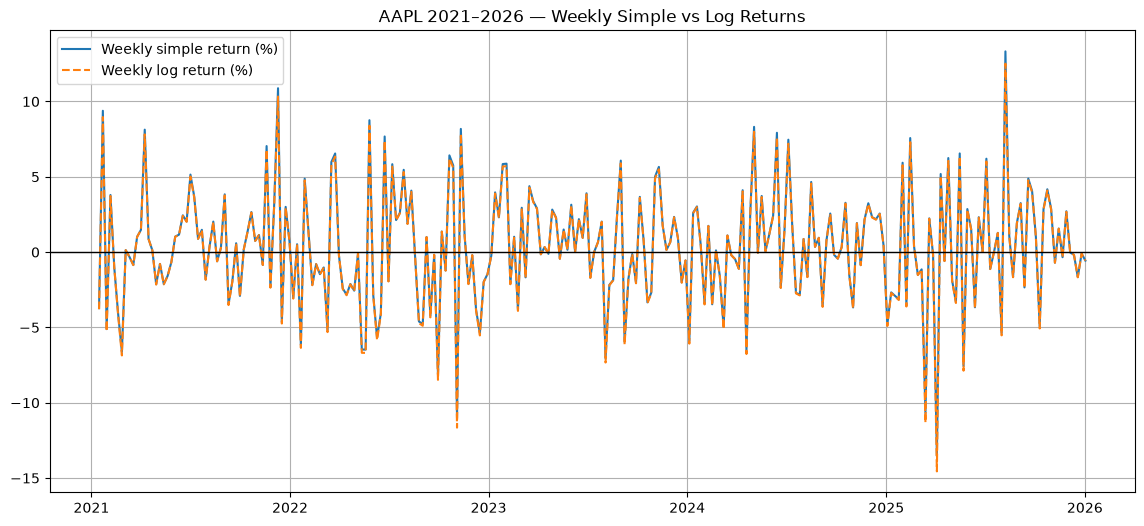

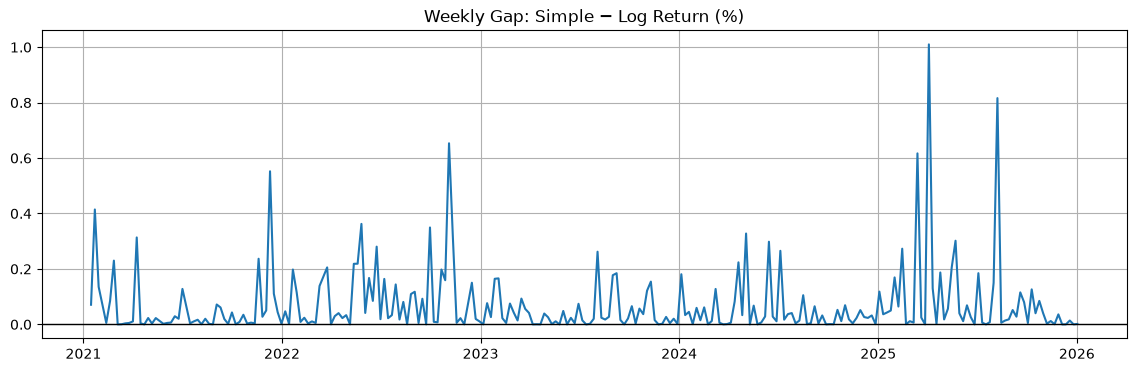

In [17]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["simple_return_pct"], label="Weekly simple return (%)")
plt.plot(df.index, df["log_return_pct"], label="Weekly log return (%)", linestyle="--")
plt.axhline(0, color="black", linewidth=1)
plt.title("AAPL 2021–2026 — Weekly Simple vs Log Returns")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(df.index, df["return_gap_pct"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Weekly Gap: Simple − Log Return (%)")
plt.grid(True)
plt.show()

Almost identical, just to show that under a certain pcnt in returns (>10%), the gap is neglibigle

In [19]:
mean_simple = returns_clean["simple_return"].mean()*100
mean_log = returns_clean["log_return"].mean()*100
var_log = returns_clean["log_return"].var()*100

print("Mean weekly simple return (%):", mean_simple)
print("Mean weekly log return (%):", mean_log)
print("Approx volatility drag (var/2) (%):", var_log / 2)

Mean weekly simple return (%): 0.35878559913935426
Mean weekly log return (%): 0.28808200290710473
Approx volatility drag (var/2) (%): 0.0705031425733034


Giving context on a weekly prospective, rather than a day to day, in which the gap is substantially smaller, compared to the volatility drag

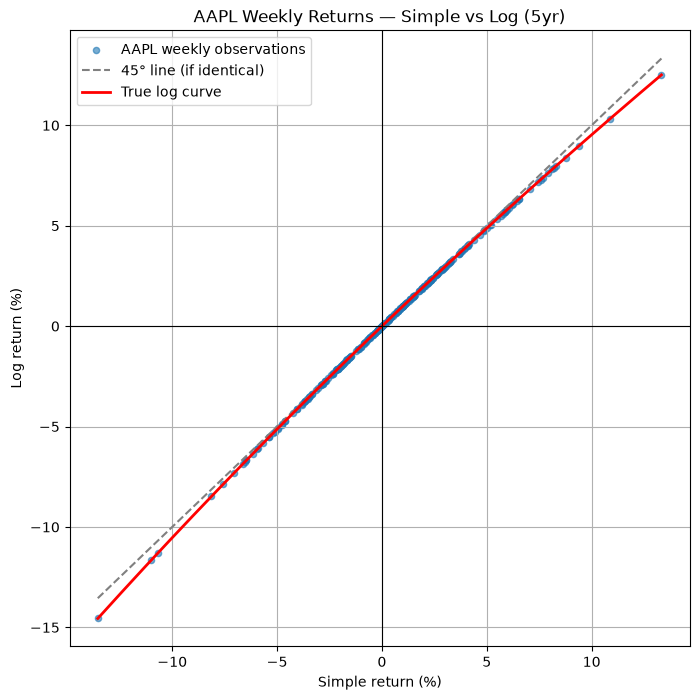

In [13]:
x = returns_clean["simple_return_pct"]
y = returns_clean["log_return_pct"]

x_grid = np.linspace(x.min(), x.max(), 500)
log_curve = 100 * np.log1p(x_grid / 100)

plt.figure(figsize=(8, 8))
plt.scatter(x, y, alpha=0.6, s=20, label="AAPL weekly observations")
plt.plot(x_grid, x_grid, linestyle="--", color="gray", label="45° line (if identical)")
plt.plot(x_grid, log_curve, linewidth=2, color="red", label="True log curve")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("AAPL Weekly Returns — Simple vs Log (5yr)")
plt.xlabel("Simple return (%)")
plt.ylabel("Log return (%)")
plt.legend()
plt.grid(True)
plt.show()

Proves the relationship is deterministic, not statistical. Every other view could be explained away as "noise" or "coincidence over time" — this one can't. If the dots sit exactly on the red curve with zero scatter around it, you've shown log return is an exact function of simple return, not a correlated-but-separate variable. No amount of averaging or time-series plotting proves functional determinism the way a scatter against the closed-form curve does.


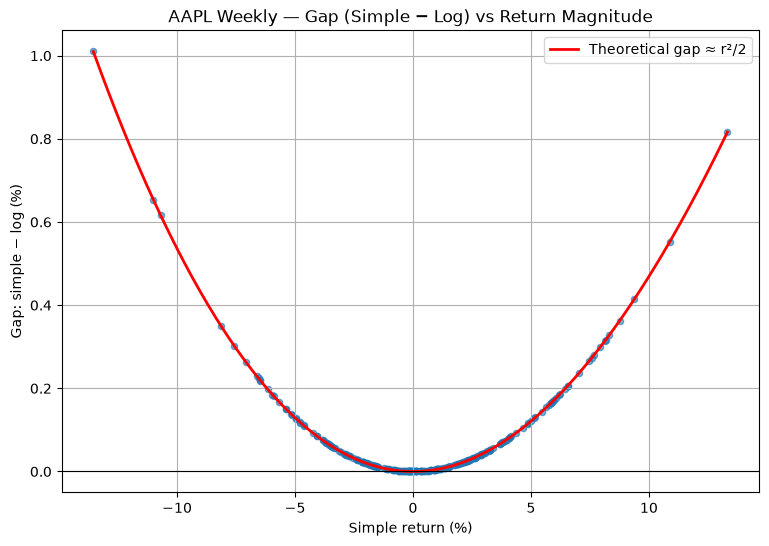

In [14]:
plt.figure(figsize=(9, 6))
plt.scatter(returns_clean["simple_return_pct"], returns_clean["return_gap_pct"], alpha=0.6, s=20)

# theoretical curve: gap ≈ r - ln(1+r) ≈ r²/2
r_grid = np.linspace(returns_clean["simple_return_pct"].min(),
                      returns_clean["simple_return_pct"].max(), 500)
gap_theory = r_grid - 100 * np.log1p(r_grid / 100)

plt.plot(r_grid, gap_theory, color="red", linewidth=2, label="Theoretical gap ≈ r²/2")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("AAPL Weekly — Gap (Simple − Log) vs Return Magnitude")
plt.xlabel("Simple return (%)")
plt.ylabel("Gap: simple − log (%)")
plt.legend()
plt.grid(True)
plt.show()

Isolates the shape of the error term in isolation from price direction and time. It answers one specific question no other view can: is the simple/log divergence symmetric or asymmetric in magnitude? By plotting gap directly against r, you strip away everything except the pure r - ln(1+r) ≈ r²/2 relationship. The U-shape proves the divergence is driven by magnitude of the move, not its sign — a down-week and an up-week of equal size produce (almost) the same gap. That specific fact — that it's magnitude-driven, not direction-driven — is invisible in a time-series chart and only partially visible in View 1's scatter (where direction is still on the x-axis, mixing the two effects together).

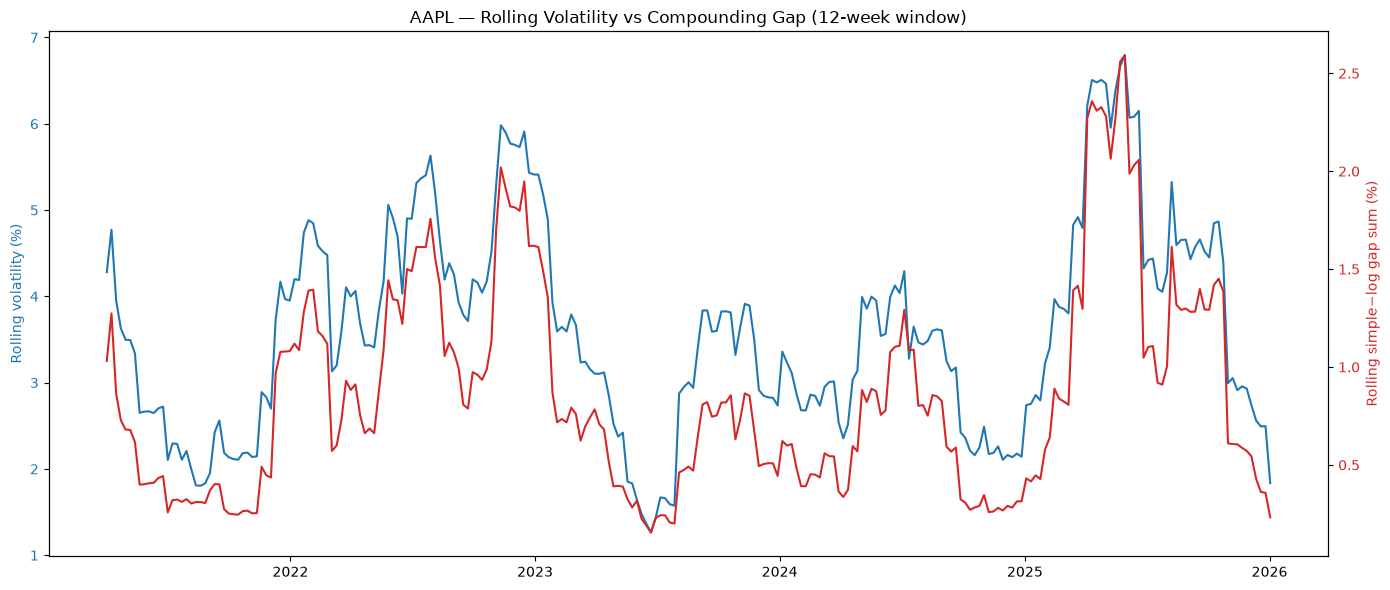

In [15]:
window = 12  # ~12 weeks ≈ 1 quarter

df["rolling_vol"] = df["log_return"].rolling(window).std()
df["rolling_gap_sum"] = df["return_gap_pct"].rolling(window).sum()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df.index, df["rolling_vol"] * 100, color="tab:blue", label="Rolling volatility (%, log std)")
ax1.set_ylabel("Rolling volatility (%)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(df.index, df["rolling_gap_sum"], color="tab:red", label="Rolling gap sum (%)")
ax2.set_ylabel("Rolling simple−log gap sum (%)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("AAPL — Rolling Volatility vs Compounding Gap (12-week window)")
fig.tight_layout()
plt.show()

bridges the math to portfolio consequence over time. Views 1 and 2 are cross-sectional/static — they prove the relationship exists and its shape, but say nothing about when it matters. View 3 answers: does this theoretical curiosity actually show up in real compounding outcomes during specific market regimes? By overlaying rolling realized volatility with the rolling sum of the gap, you demonstrate that the effect isn't a constant tax — it clusters during high-volatility periods (crashes, earnings shocks, 2022 drawdown, etc.) and nearly disappears in calm regimes. This is the only view that turns an algebraic fact into a time-varying, regime-dependent risk statement — which is what actually matters for portfolio return expectations and why "arithmetic mean overstates long-run growth" gets worse specifically when volatility spikes.